# Setup

In [2]:
!pip install transformers datasets biopython accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 40.6 MB/s eta 0:00:00


# k-mer classification

In [20]:
import gzip
from Bio import SeqIO
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def load_fasta(file_path, label):
    sequences = []
    labels = []
    with gzip.open(file_path, "rt") as handle:
        for record in SeqIO.parse(handle, "fasta"):
            seq = str(record.seq).upper()
            kmers = [seq[i:i+5] for i in range(len(seq) - 4)]
            sequences.append(" ".join(kmers))
            labels.append(label)
    return sequences, labels

v_seqs, v_labs = load_fasta("viral_BEST.fasta.gz", 1)
h_seqs, h_labs = load_fasta("human_BEST.fasta.gz", 0)

X_k= v_seqs + h_seqs
y_k = v_labs + h_labs
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_k, y_k, test_size=0.2, stratify=y)

vectorizer = TfidfVectorizer(max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train_k)
X_test_vec = vectorizer.transform(X_test_k)

clf = RandomForestClassifier(n_estimators=10, n_jobs=-1)
clf.fit(X_train_vec, y_train_k)

y_pred = clf.predict(X_test_vec)
print(classification_report(y_test_k, y_pred, target_names=['Human', 'Viral']))

              precision    recall  f1-score   support

       Human       0.84      0.98      0.90      4071
       Viral       0.85      0.40      0.54      1284

    accuracy                           0.84      5355
   macro avg       0.84      0.69      0.72      5355
weighted avg       0.84      0.84      0.82      5355



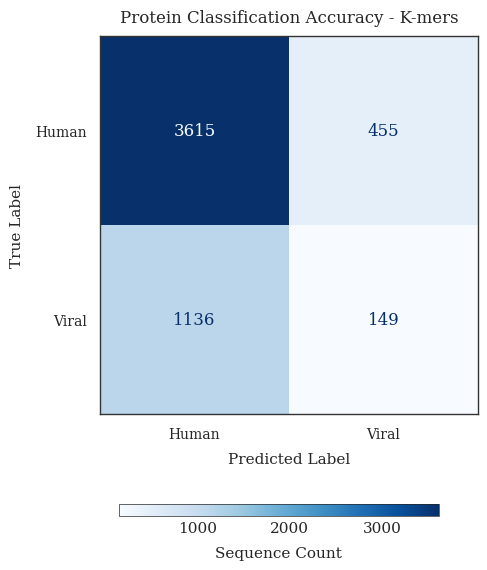

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", font="serif")
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

disp = ConfusionMatrixDisplay.from_estimator(
    clf, X_test_vec, y_test,
    display_labels=['Human', 'Viral'],
    cmap='Blues',
    ax=ax,
    colorbar=False
)

ax.set_title("Protein Classification Accuracy - K-mers",
             fontsize=12, family='serif', pad=10)

ax.set_xlabel('Predicted Label', fontsize=11, family='serif', labelpad=8)
ax.set_ylabel('True Label', fontsize=11, family='serif', labelpad=8)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')
    label.set_fontsize(10)

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#333333')
    ax.spines[spine].set_linewidth(1.0)

cbar_ax = fig.add_axes([0.3, 0.08, 0.4, 0.02])
cbar = fig.colorbar(ax.images[0], cax=cbar_ax, orientation='horizontal')
cbar.set_label('Sequence Count', fontsize=11, family='serif', labelpad=8)
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(size=0)

for t in cbar.ax.get_xticklabels():
    t.set_family('serif')

plt.subplots_adjust(bottom=0.25)
plt.show()

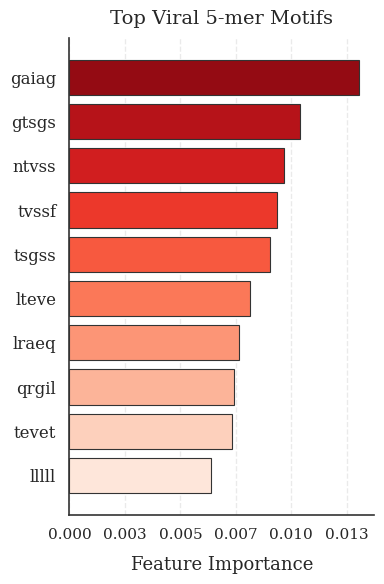

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

importances = clf.feature_importances_
indices = np.argsort(importances)[-10:]
features = vectorizer.get_feature_names_out()

plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(4, 6), facecolor='white')

colors = sns.color_palette("Reds", len(indices))

ax.barh(range(len(indices)), importances[indices],
        color=colors,
        edgecolor='#333333',
        linewidth=0.8)

ax.set_yticks(range(len(indices)))
ax.set_yticklabels([features[i] for i in indices], fontsize=12)

ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))

ax.set_xlabel("Feature Importance", fontsize=13, labelpad=10)

ax.set_title("Top Viral 5-mer Motifs",
             fontsize=14, pad=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#333333')
    ax.spines[spine].set_linewidth(1.2)

ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Baseline Classifier

In [3]:
import pandas as pd
import numpy as np
from Bio import SeqIO
import gzip

def load_fasta(file_path, label):
    sequences = []
    with gzip.open(file_path, "rt") as handle:
        for i, record in enumerate(SeqIO.parse(handle, "fasta")):
            sequences.append({"sequence": str(record.seq), "label": label})
    return sequences

virus_data = load_fasta("viral_BEST.fasta.gz", 1)
human_data = load_fasta("human_BEST.fasta.gz", 0)
df = pd.DataFrame(virus_data + human_data).sample(frac=1).reset_index(drop=True)

In [8]:
len(virus_data)

6350

In [8]:
import torch
import transformers
import pandas as pd
import numpy as np
from Bio import SeqIO
import gzip
from transformers import AutoTokenizer, EsmModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

def load_fasta(file_path, label):
    sequences = []
    with gzip.open(file_path, "rt") as handle:
        for i, record in enumerate(SeqIO.parse(handle, "fasta")):
            sequences.append({"sequence": str(record.seq), "label": label})
    return sequences

virus_data = load_fasta("viral_BEST.fasta.gz", 1)
human_data = load_fasta("human_BEST.fasta.gz", 0)
df = pd.DataFrame(virus_data + human_data).sample(frac=1).reset_index(drop=True)

model_name = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = EsmModel.from_pretrained(model_name, torch_dtype=torch.float16).to(device)
model.eval()

def get_embeddings_batched(sequence_list, batch_size=8):
    all_embeddings = []

    # Process in batches to utilize GPU parallelization
    for i in tqdm(range(0, len(sequence_list), batch_size)):
        batch_seqs = [s[:1024] for s in sequence_list[i : i + batch_size]]

        inputs = tokenizer(
            batch_seqs,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

            mask = inputs['attention_mask'].unsqueeze(-1)
            embeddings = (outputs.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)
            all_embeddings.append(embeddings.cpu().float().numpy())

    return np.concatenate(all_embeddings, axis=0)

print(f"Extracting features using {model_name}...")
X = get_embeddings_batched(df['sequence'].tolist(), batch_size=8)
y = df['label'].values

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Using device: cuda


model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


EsmModel(
  (embeddings): EsmEmbeddings(
    (word_embeddings): Embedding(33, 1280, padding_idx=1)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): EsmEncoder(
    (layer): ModuleList(
      (0-32): 33 x EsmLayer(
        (attention): EsmAttention(
          (self): EsmSelfAttention(
            (query): Linear(in_features=1280, out_features=1280, bias=True)
            (key): Linear(in_features=1280, out_features=1280, bias=True)
            (value): Linear(in_features=1280, out_features=1280, bias=True)
            (rotary_embeddings): RotaryEmbedding()
          )
          (output): EsmSelfOutput(
            (dense): Linear(in_features=1280, out_features=1280, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (LayerNorm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        )
        (intermediate): EsmIntermediate(
          (dense): Linear(in_features=1280, out_features=5120, bias=True)
        )
        (output): EsmOut

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf_reg = LogisticRegression(max_iter=1000)
clf_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [54]:
y_pred = clf_reg.predict(X_test)

In [55]:
print(classification_report(y_test, y_pred, target_names=['Human', 'Viral']))

              precision    recall  f1-score   support

       Human       0.99      0.98      0.98      4085
       Viral       0.95      0.96      0.95      1270

    accuracy                           0.98      5355
   macro avg       0.97      0.97      0.97      5355
weighted avg       0.98      0.98      0.98      5355



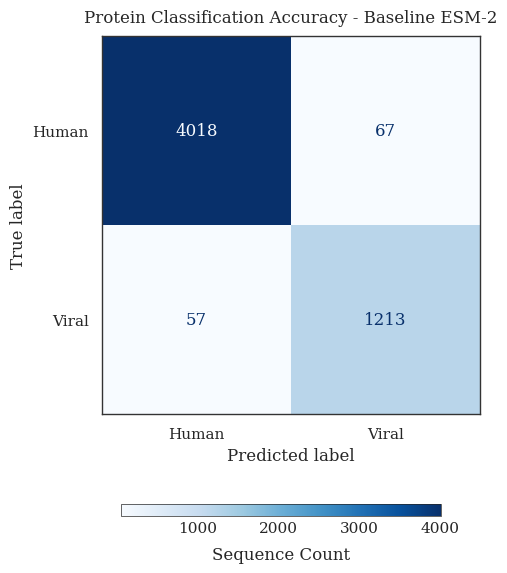

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

disp = ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test,
    display_labels=['Human', 'Viral'],
    cmap='Blues',
    ax=ax,
    colorbar=False
)

ax.set_title("Protein Classification Accuracy - Baseline ESM-2",
             fontsize=12, pad=10)

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#333333')
    ax.spines[spine].set_linewidth(1.0)

cbar_ax = fig.add_axes([0.3, 0.08, 0.4, 0.02])
cbar = fig.colorbar(ax.images[0], cax=cbar_ax, orientation='horizontal')
cbar.set_label('Sequence Count', fontsize=12, labelpad=8)
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(size=0)

plt.subplots_adjust(bottom=0.25)
plt.show()

In [ ]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(X)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


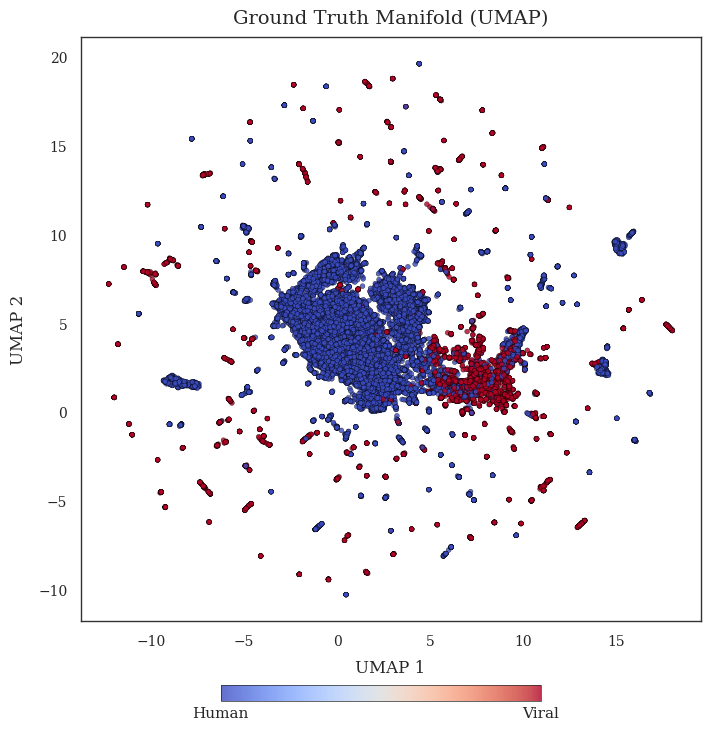

In [ ]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="white", font="serif")
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')

scatter = ax.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=y,
    cmap='coolwarm',
    s=12,
    alpha=0.8,
    edgecolors='black',
    linewidth=0.3,
    zorder=2
)

ax.set_title('Ground Truth Manifold (UMAP)',
             fontsize=14, family='serif', pad=10)

ax.set_xlabel('UMAP 1', fontsize=12, family='serif', labelpad=8)
ax.set_ylabel('UMAP 2', fontsize=12, family='serif', labelpad=8)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')
    label.set_fontsize(10)

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#333333')
    ax.spines[spine].set_linewidth(1.0)

cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02])
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')

cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Human', 'Viral'], fontsize=11, family='serif')
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(size=0)

for t in cbar.ax.get_xticklabels():
    t.set_family('serif')

plt.subplots_adjust(bottom=0.15)
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

pca_orig = PCA(n_components=2)
X_pca = pca_orig.fit_transform(X)

var_exp = pca_orig.explained_variance_ratio_

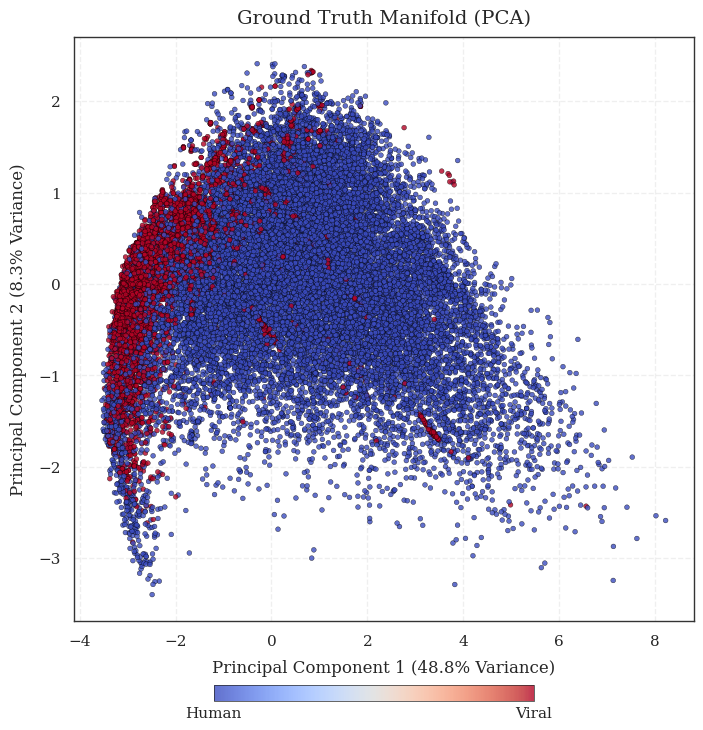

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", font="serif")
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='coolwarm',
    s=12,
    alpha=0.8,
    edgecolors='black',
    linewidth=0.3,
    zorder=2
)

ax.set_title('Ground Truth Manifold (PCA)',
             fontsize=14, family='serif', pad=10)

ax.set_xlabel(f'Principal Component 1 ({var_exp[0]:.1%} Variance)',
              fontsize=12, family='serif', labelpad=8)
ax.set_ylabel(f'Principal Component 2 ({var_exp[1]:.1%} Variance)',
              fontsize=12, family='serif', labelpad=8)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#333333')
    ax.spines[spine].set_linewidth(1.0)

cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02])
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')

cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Human', 'Viral'], fontsize=11, family='serif')
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(size=0)

for t in cbar.ax.get_xticklabels():
    t.set_family('serif')

ax.grid(True, linestyle='--', alpha=0.3, zorder=1)

plt.subplots_adjust(bottom=0.15)
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


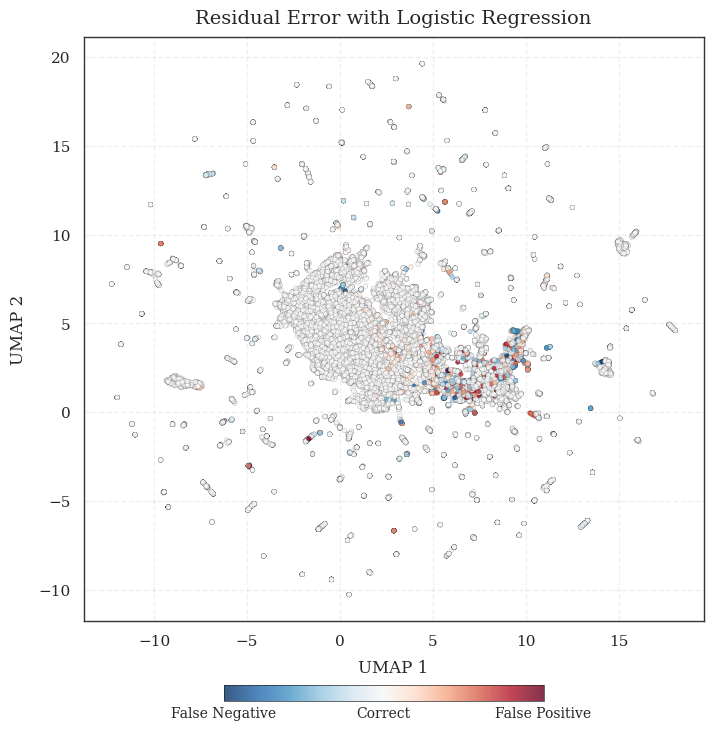

In [ ]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", font="serif")
plt.rcParams['font.family'] = 'serif'

probs = clf.predict_proba(X)[:, 1]
errors = probs - y

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')

scatter = ax.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=errors,
    cmap='RdBu_r',
    s=12,
    alpha=0.8,
    edgecolors='black',
    linewidth=0.1,
    vmin=-1,
    vmax=1,
    zorder=2
)

ax.set_title('Residual Error with Logistic Regression',
             fontsize=14, family='serif', pad=10)

ax.set_xlabel('UMAP 1', fontsize=12, family='serif', labelpad=8)
ax.set_ylabel('UMAP 2', fontsize=12, family='serif', labelpad=8)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#333333')
    ax.spines[spine].set_linewidth(1.0)

cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02])
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')

cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['False Negative', 'Correct', 'False Positive'],
                    fontsize=10, family='serif')
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(size=0)

for t in cbar.ax.get_xticklabels():
    t.set_family('serif')

ax.grid(True, linestyle='--', alpha=0.3, zorder=1)

plt.subplots_adjust(bottom=0.15)
plt.show()

## Supervised Contrastive (SupCon)

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)
X_all_t = torch.tensor(X, dtype=torch.float32).to(device)

batch_size = 256
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True
)

class ProjectionHead(nn.Module):
    def __init__(self, input_dim=X.shape[1], hidden_dim=640, output_dim=320):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.normalize(x, p=2, dim=1)

def simplified_supcon_loss(embeddings, labels, temperature=0.15):
    cosine_sim = torch.matmul(embeddings, embeddings.T) / temperature
    labels = labels.contiguous().view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(device)
    logits_mask = torch.scatter(
        torch.ones_like(mask),
        1,
        torch.arange(mask.shape[0]).view(-1, 1).to(device),
        0
    )
    mask = mask * logits_mask
    logits_max, _ = torch.max(cosine_sim, dim=1, keepdim=True)
    logits = cosine_sim - logits_max.detach()

    exp_logits = torch.exp(logits) * logits_mask
    log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-9)
    mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-9)

    return -mean_log_prob_pos.mean()

head = ProjectionHead().to(device)
optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)

In [45]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 256
dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

head = ProjectionHead().to(device)
optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)

print("Starting Training...")
for epoch in range(101):
    epoch_loss = 0
    head.train()

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        proj_embeddings = head(batch_X)
        loss = simplified_supcon_loss(proj_embeddings, batch_y)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {epoch_loss / len(train_loader):.4f}")

Starting Training...
Epoch 0 | Loss: 5.1857
Epoch 10 | Loss: 5.0231
Epoch 20 | Loss: 4.9998
Epoch 30 | Loss: 4.9896
Epoch 40 | Loss: 4.9863
Epoch 50 | Loss: 4.9864
Epoch 60 | Loss: 4.9860
Epoch 70 | Loss: 4.9861
Epoch 80 | Loss: 4.9867
Epoch 90 | Loss: 4.9867
Epoch 100 | Loss: 4.9860


In [ ]:
head.eval()
with torch.no_grad():
    def project_in_batches(tensor, batch_size=512):
        projections = []
        for i in range(0, len(tensor), batch_size):
            batch = tensor[i : i + batch_size]
            projections.append(head(batch).cpu().numpy())
        return np.concatenate(projections, axis=0)

    X_train_proj = project_in_batches(X_train_t)
    X_test_proj = project_in_batches(X_test_t)

    X_all_proj = project_in_batches(X_all_t)

probe = LogisticRegression(max_iter=1000)
probe.fit(X_train_proj, y_train)

probs = probe.predict_proba(X_all_proj)[:, 1]
residual_errors = probs - y

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


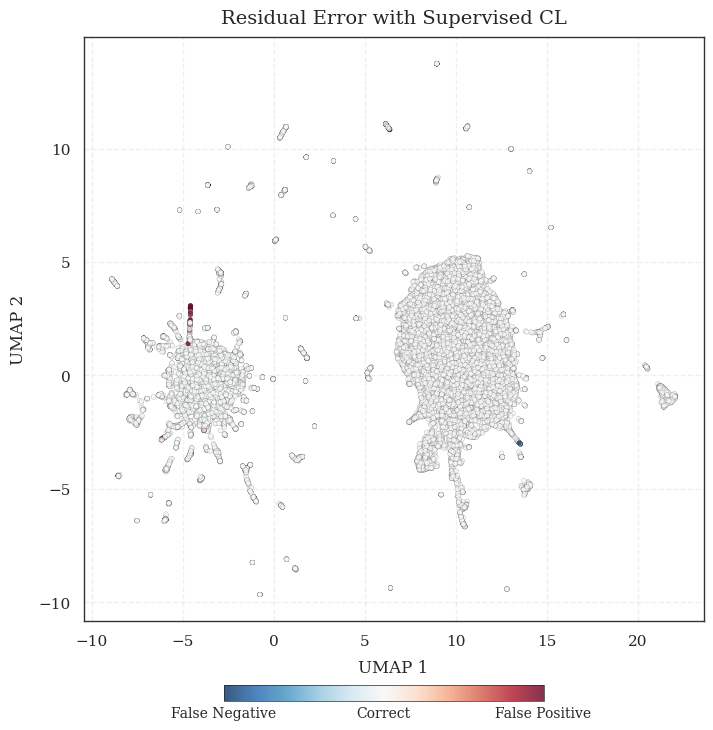

In [ ]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", font="serif")
plt.rcParams['font.family'] = 'serif'

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(X_all_proj)

fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')

scatter = ax.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=residual_errors,
    cmap='RdBu_r',
    s=12,
    alpha=0.8,
    edgecolors='black',
    linewidth=0.1,
    vmin=-1,
    vmax=1,
    zorder=2
)

ax.set_title('Residual Error with Supervised CL',
             fontsize=14, family='serif', pad=10)

ax.set_xlabel('UMAP 1', fontsize=12, family='serif', labelpad=8)
ax.set_ylabel('UMAP 2', fontsize=12, family='serif', labelpad=8)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#333333')
    ax.spines[spine].set_linewidth(1.0)

cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02])
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')

cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['False Negative', 'Correct', 'False Positive'],
                    fontsize=10, family='serif')
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(size=0)

for t in cbar.ax.get_xticklabels():
    t.set_family('serif')
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.subplots_adjust(bottom=0.15)
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


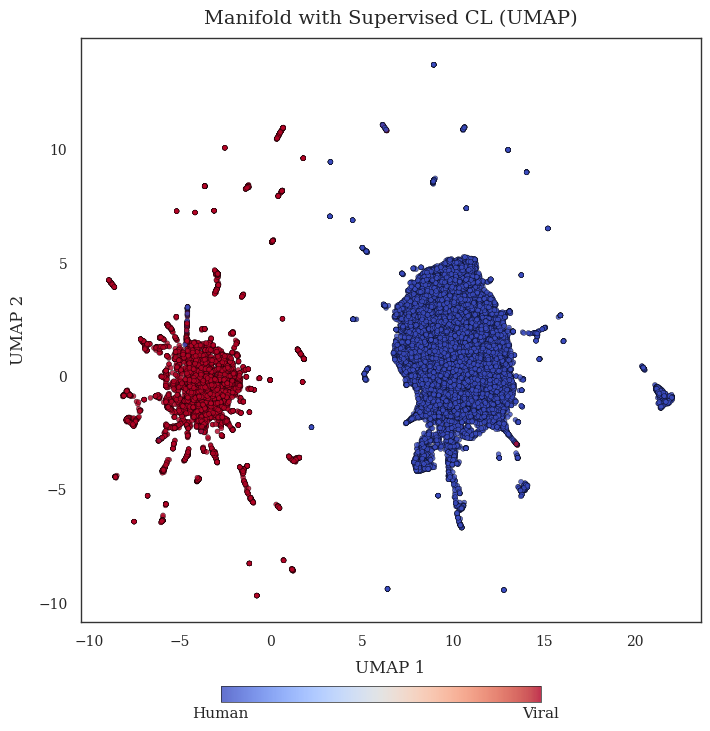

In [ ]:
import umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(X_all_proj)

sns.set_theme(style="white", font="serif")
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')

scatter = ax.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=y,
    cmap='coolwarm',
    s=12,
    alpha=0.8,
    edgecolors='black',
    linewidth=0.3,
    zorder=2
)

ax.set_title('Manifold with Supervised CL (UMAP)',
             fontsize=14, family='serif', pad=10)

ax.set_xlabel('UMAP 1', fontsize=12, family='serif', labelpad=8)
ax.set_ylabel('UMAP 2', fontsize=12, family='serif', labelpad=8)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')
    label.set_fontsize(10)

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#333333')
    ax.spines[spine].set_linewidth(1.0)

cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02])
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')

cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Human', 'Viral'], fontsize=11, family='serif')
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(size=0)

for t in cbar.ax.get_xticklabels():
    t.set_family('serif')

plt.subplots_adjust(bottom=0.15)
plt.show()

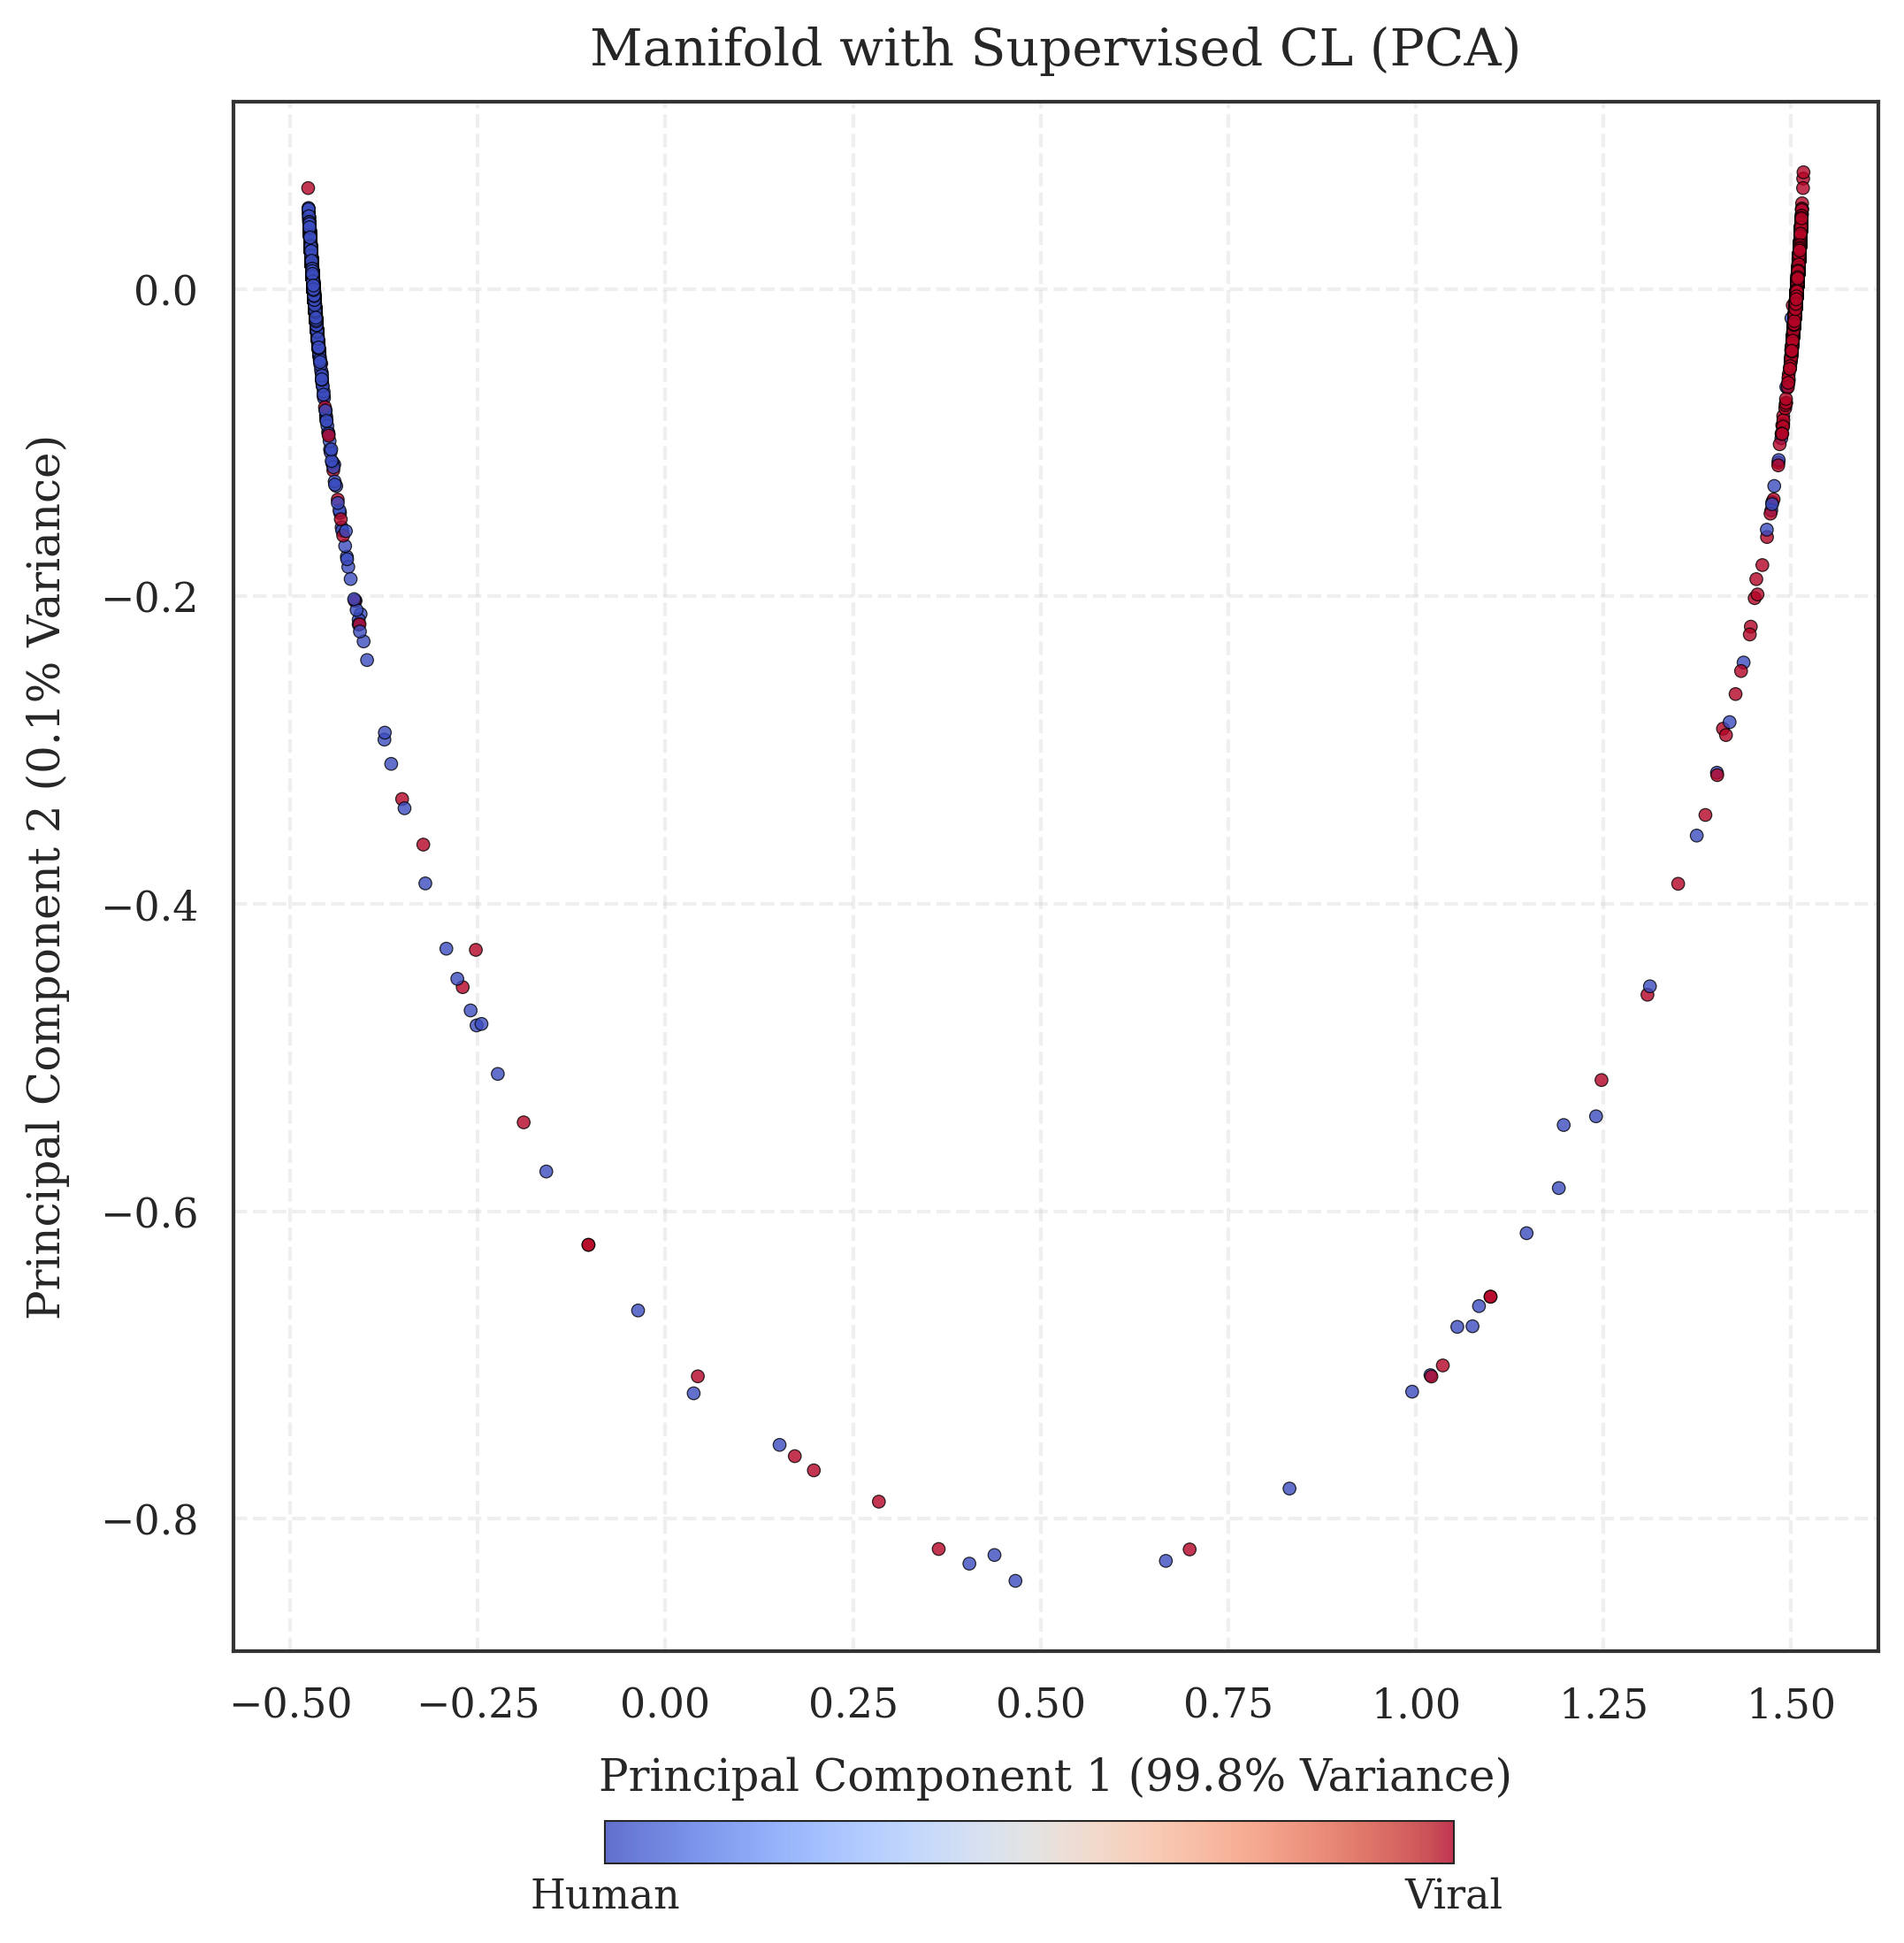

In [59]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="white", font="serif")
plt.rcParams['font.family'] = 'serif'


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all_proj)

var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 8), facecolor='white', dpi=300)

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='coolwarm',
    s=12,
    alpha=0.8,
    edgecolors='black',
    linewidth=0.3,
    zorder=2
)

ax.set_title('Manifold with Supervised CL (PCA)',
             fontsize=14, family='serif', pad=10)

ax.set_xlabel(f'Principal Component 1 ({var_exp[0]:.1%} Variance)',
              fontsize=12, family='serif', labelpad=8)
ax.set_ylabel(f'Principal Component 2 ({var_exp[1]:.1%} Variance)',
              fontsize=12, family='serif', labelpad=8)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#333333')
    ax.spines[spine].set_linewidth(1.0)

cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02])
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')

cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Human', 'Viral'], fontsize=11, family='serif')
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(size=0)

for t in cbar.ax.get_xticklabels():
    t.set_family('serif')

ax.grid(True, linestyle='--', alpha=0.3, zorder=1)

plt.subplots_adjust(bottom=0.15)
plt.show()

Overall Accuracy: 98.69%
------------------------------
Classification Report:
              precision    recall  f1-score   support

       Human       0.99      0.99      0.99      4085
       Viral       0.97      0.97      0.97      1270

    accuracy                           0.99      5355
   macro avg       0.98      0.98      0.98      5355
weighted avg       0.99      0.99      0.99      5355



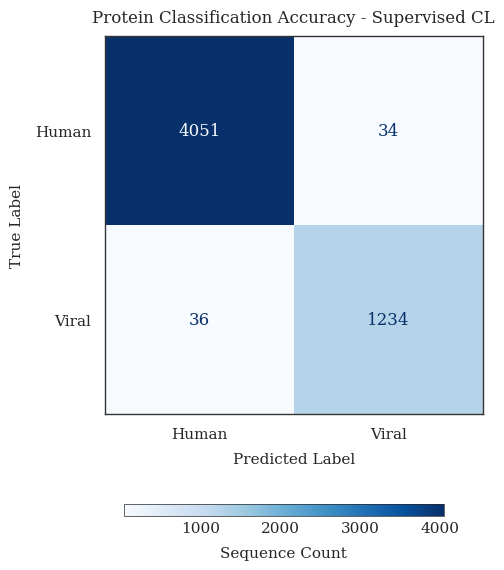

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

sns.set_theme(style="white", font="serif")
plt.rcParams['font.family'] = 'serif'

y_pred = probe.predict(X_test_proj)

acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc:.2%}")
print("-" * 30)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Human", "Viral"]))

fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Human', 'Viral'],
    cmap='Blues',
    ax=ax,
    colorbar=False
)

ax.set_title("Protein Classification Accuracy - Supervised CL",
             fontsize=12, family='serif', pad=10)

ax.set_xlabel('Predicted Label', fontsize=11, family='serif', labelpad=8)
ax.set_ylabel('True Label', fontsize=11, family='serif', labelpad=8)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#333333')
    ax.spines[spine].set_linewidth(1.0)

cbar_ax = fig.add_axes([0.3, 0.08, 0.4, 0.02])
cbar = fig.colorbar(ax.images[0], cax=cbar_ax, orientation='horizontal')
cbar.set_label('Sequence Count', fontsize=11, family='serif', labelpad=8)
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(size=0)

for t in cbar.ax.get_xticklabels():
    t.set_family('serif')

plt.subplots_adjust(bottom=0.25)
plt.show()

Training and capturing manifold evolution...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:

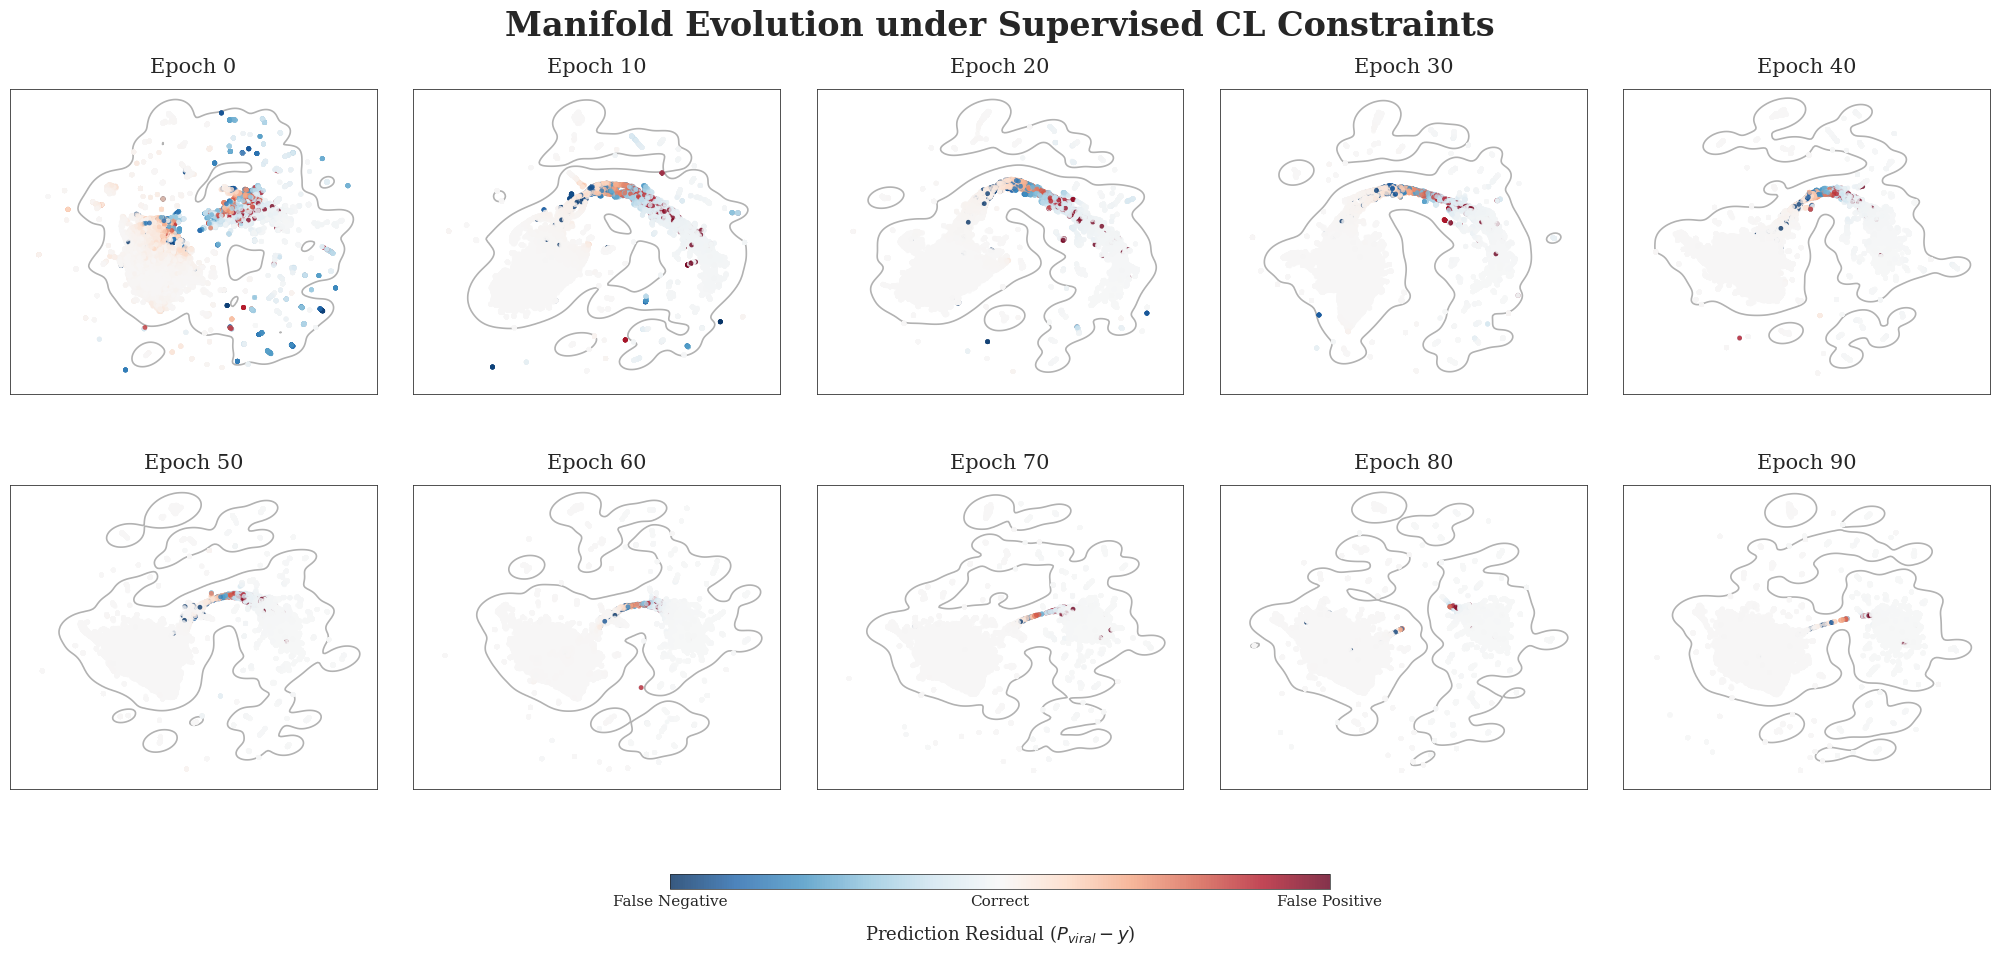

In [ ]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

sns.set_theme(style="white")
accent_cmap = 'RdBu_r'

snapshots = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
snapshot_data = {}
snapshot_errors = {}

head = ProjectionHead().to(device)
optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)

for epoch in range(91):
    head.train()
    optimizer.zero_grad()
    proj_embeddings = head(X_train_t)
    loss = simplified_supcon_loss(proj_embeddings, y_train_t)
    loss.backward()
    optimizer.step()

    if epoch in snapshots:
        head.eval()
        with torch.no_grad():
            current_proj = head(X_all_t).cpu().numpy()
            snapshot_data[epoch] = current_proj

            X_train_proj = head(X_train_t).cpu().numpy()
            temp_probe = LogisticRegression(max_iter=1000).fit(X_train_proj, y_train)
            probs = temp_probe.predict_proba(current_proj)[:, 1]
            snapshot_errors[epoch] = probs - y

anchor_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
anchor_coords = anchor_reducer.fit_transform(snapshot_data[90])

fig, axes = plt.subplots(2, 5, figsize=(22, 10), facecolor='white')
axes = axes.flatten()

for i, epoch in enumerate(snapshots):
    ax = axes[i]

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine',
                       init=anchor_coords, random_state=42)
    embedding_2d = reducer.fit_transform(snapshot_data[epoch])

    sns.kdeplot(
        x=embedding_2d[:, 0], y=embedding_2d[:, 1],
        color='black', linewidths=1.2, alpha=0.3,
        levels=[0.025],
        ax=ax, zorder=1
    )

    scatter = ax.scatter(
        embedding_2d[:, 0], embedding_2d[:, 1],
        c=snapshot_errors[epoch],
        cmap=accent_cmap,
        s=12,
        alpha=0.8,
        edgecolors='none',
        vmin=-1, vmax=1,
        zorder=2
    )

    ax.set_title(f"Epoch {epoch}", fontsize=15, fontweight='medium', family='serif', pad=12)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
        spine.set_linewidth(0.6)

cbar_ax = fig.add_axes([0.35, 0.08, 0.3, 0.015])
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')

cbar.set_label('Prediction Residual ($P_{viral} - y$)', fontsize=13, family='serif', labelpad=10)
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['False Negative', 'Correct', 'False Positive'], fontsize=11, family='serif')

cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(size=0)

plt.suptitle("Manifold Evolution under Supervised CL Constraints",
             fontsize=24, fontweight='bold', y=0.96, family='serif')

plt.subplots_adjust(wspace=0.1, hspace=0.3, bottom=0.18, top=0.88, left=0.05, right=0.95)
plt.show()

# Hard cases

In [14]:
from sklearn.neighbors import NearestNeighbors

def find_hard_cases(X, y, n_neighbors=5):
    # Find points where the closest neighbors have DIFFERENT labels
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine')
    nn.fit(X)
    distances, indices = nn.kneighbors(X)

    hard_case_indices = []
    for i in range(len(X)):
        neighbor_labels = y[indices[i][1:]]
        if y[i] == 1 and 0 in neighbor_labels:
            hard_case_indices.append(i)
        elif y[i] == 0 and 1 in neighbor_labels:
            hard_case_indices.append(i)

    return hard_case_indices

hard_indices = find_hard_cases(X, y)
print(f"Found {len(hard_indices)} Hard Cases")

Found 1404 Hard Cases where biology overlaps in latent space.


In [25]:
# MODEL 0: k-mer classifier w/o ESM-2
X_hard_kmers = [X_k[i] for i in hard_indices]
X_hard_vec = vectorizer.transform(X_hard_kmers)
y_pred_kmer = clf.predict(X_hard_vec)

# MODEL 1: REGULAR (LogReg on raw ESM-2)
clf_reg = LogisticRegression(max_iter=1000)
clf_reg.fit(X_train, y_train)
y_pred_reg = clf_reg.predict(X[hard_indices])

# MODEL 2: CONTRASTIVE
head.eval()
with torch.no_grad():
    X_hard_t = torch.tensor(X[hard_indices], dtype=torch.float32).to(device)
    X_hard_proj = head(X_hard_t).cpu().numpy()

y_pred_con = probe.predict(X_hard_proj)

/tmp/ipykernel_3773/1135407505.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


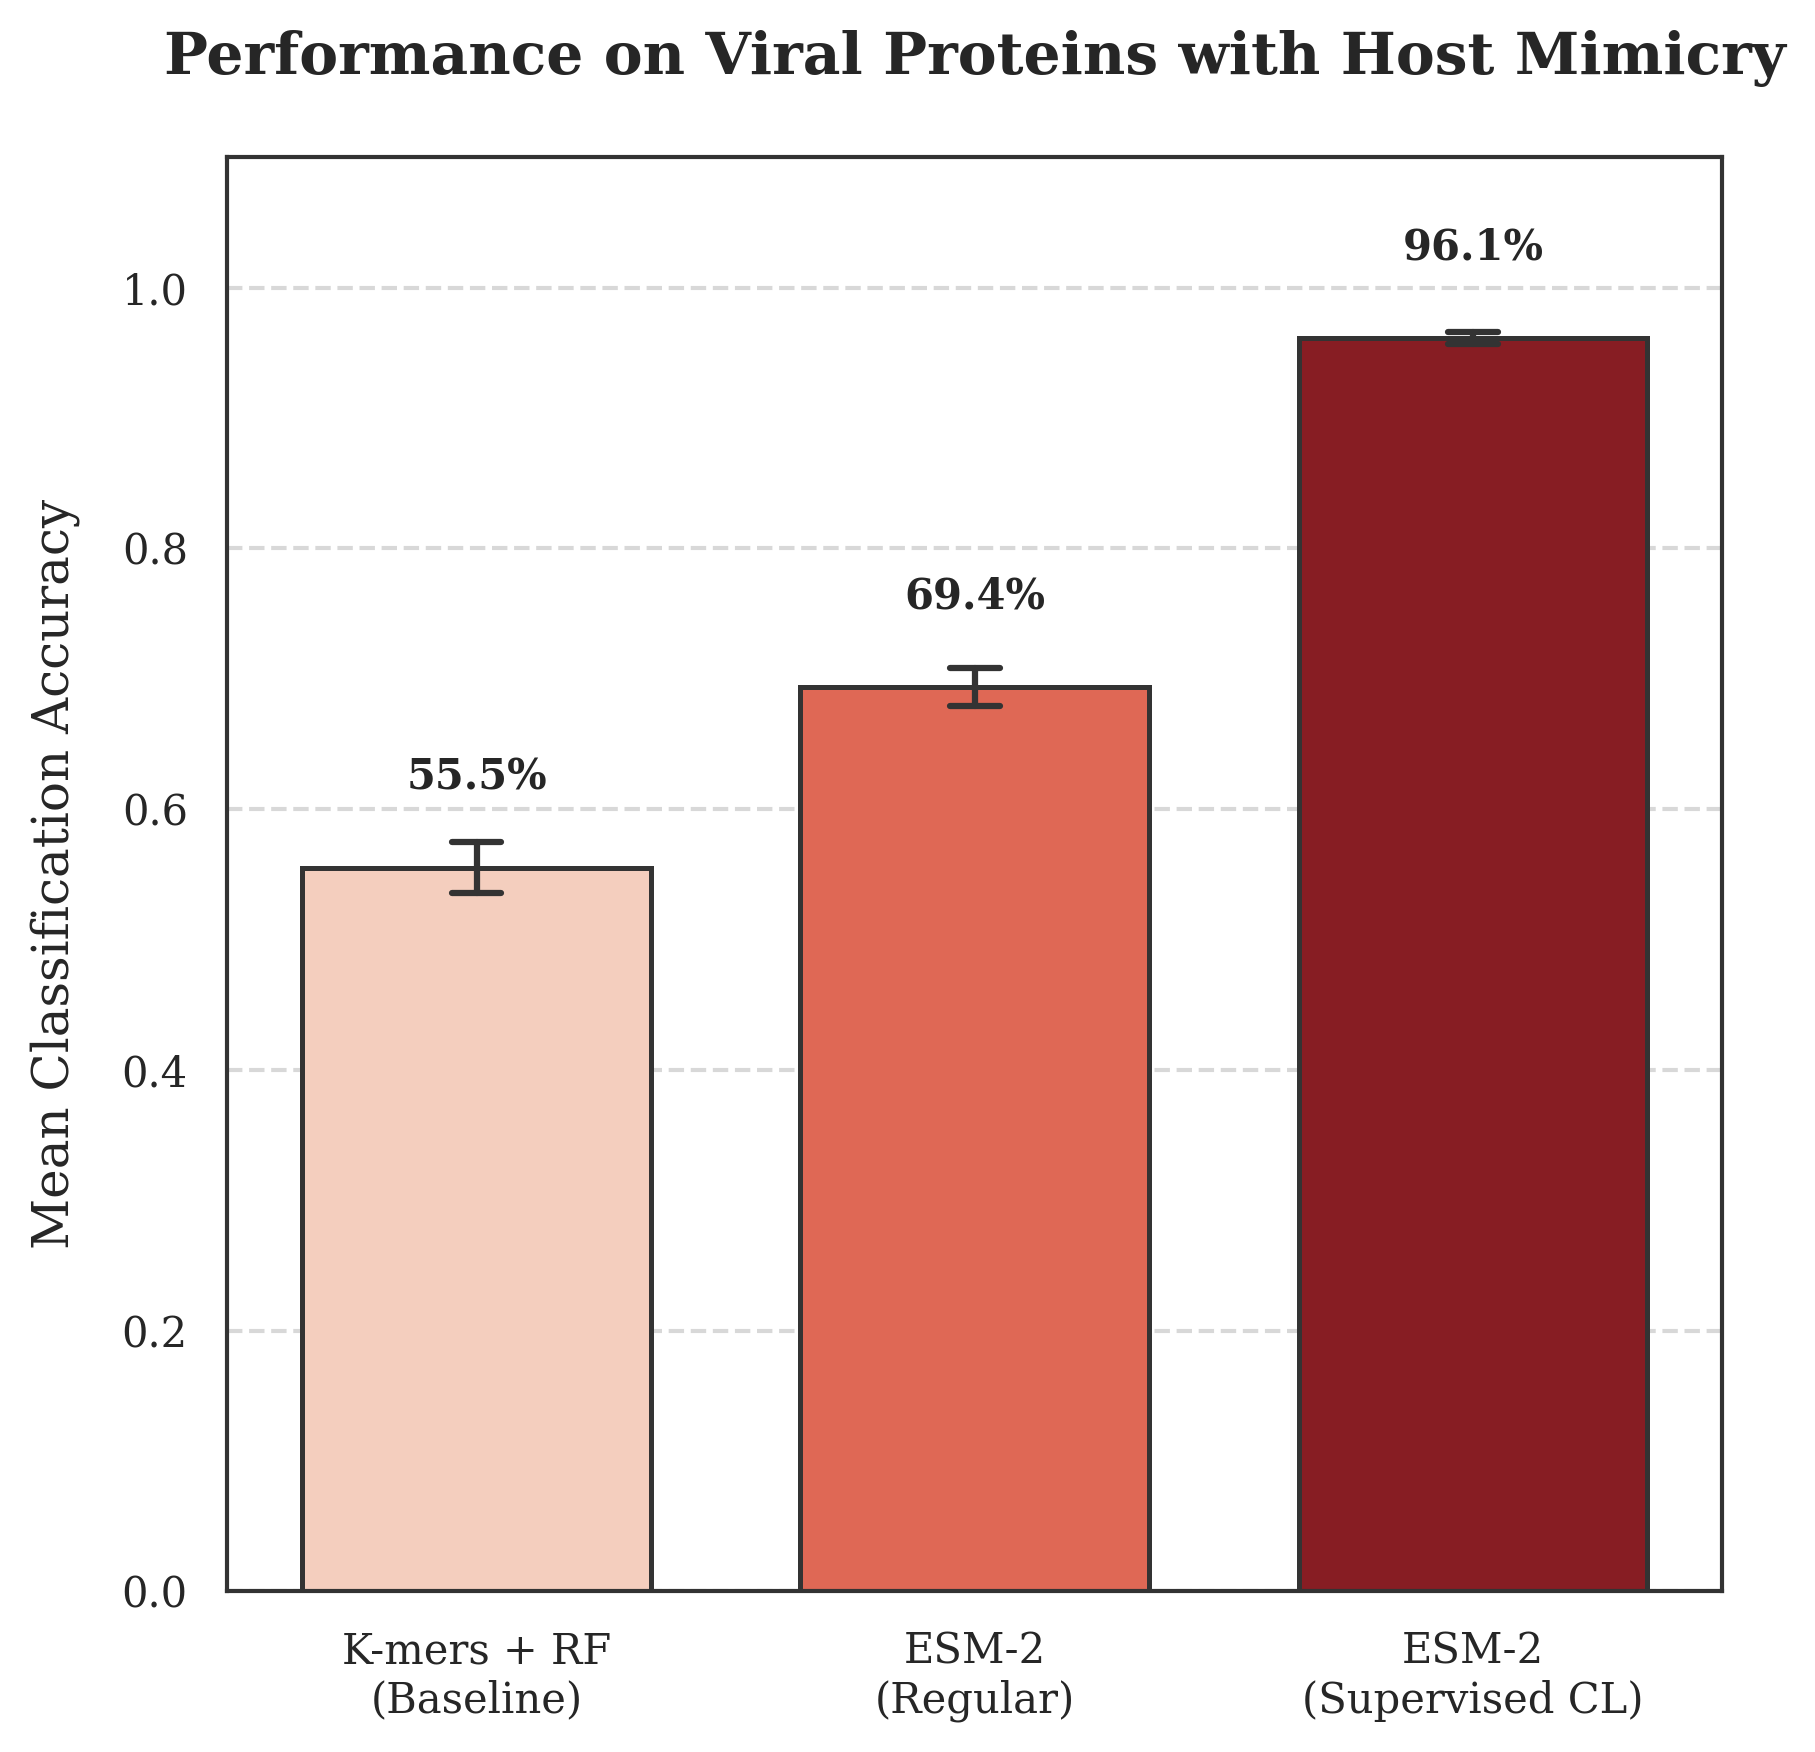

In [40]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import resample

n_iterations = 5
stats_data = []

y_hard_true = np.array(y)[hard_indices]

for i in range(n_iterations):
    boot_indices = resample(np.arange(len(y_hard_true)), replace=True, random_state=i)

    acc_k = accuracy_score(y_hard_true[boot_indices], y_pred_kmer[boot_indices])
    acc_reg = accuracy_score(y_hard_true[boot_indices], y_pred_reg[boot_indices])
    acc_con = accuracy_score(y_hard_true[boot_indices], y_pred_con[boot_indices])

    stats_data.append(['K-mers + RF\n(Baseline)', acc_k])
    stats_data.append(['ESM-2\n(Regular)', acc_reg])
    stats_data.append(['ESM-2\n(Supervised CL)', acc_con])

df_stats = pd.DataFrame(stats_data, columns=['Model', 'Accuracy'])

sns.set_theme(style="white", font="serif")
plt.rcParams['font.family'] = 'serif'
colors = ["#FDCAB5", "#F6583E", "#980C13"]

fig, ax = plt.subplots(figsize=(6, 6), facecolor='white', dpi=300)

sns.barplot(
    data=df_stats,
    x='Model',
    y='Accuracy',
    palette=colors,
    ax=ax,
    edgecolor="#333333",
    linewidth=1.2,
    errorbar='sd',
    capsize=0.1,
    width=0.7,
    err_kws={'linewidth': 1.5, 'color': '#333333'}
)

ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

ax.set_title('Performance on Viral Proteins with Host Mimicry', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Mean Classification Accuracy', fontsize=12, labelpad=10)
ax.set_xlabel('', fontsize=12)
ax.set_ylim(0, 1.1)

means = df_stats.groupby('Model', sort=False)['Accuracy'].mean()
for i, m in enumerate(means):
    ax.text(i, m + 0.06, f"{m:.1%}", ha='center', weight='bold', family='serif', size=10)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#333333')
    spine.set_linewidth(1.0)

plt.xticks(family='serif', size=10)
plt.yticks(family='serif', size=10)

plt.tight_layout()
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.3)
ax.set_axisbelow(True)
plt.show()